# Fig 1 — cancer/normal classification across primary & metastatic CRC

Reproduces **Fig1** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

> Excluded (non-code): Fig 1a schematic, Fig 1d H&E/ROI micrographs.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Fig 1 — shared setup (build results{})
**🔴 heavy (GPU / multi-GB / long)** · source: `eval_confusion_matrices.ipynb cell 1,3,5,7`

In [ ]:
sys.path[:0]=[str(REPO_ROOT/'scripts'), str(NB)]
# --- cell 1: imports + config ------------------------------------------------
%matplotlib inline
import sys
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc,
)

sys.path.insert(0, str(Path('../scripts').resolve()))
# Reload in case the module was imported earlier in this kernel session
import gxd_split_config; importlib.reload(gxd_split_config)
import gxd_he_overlay;   importlib.reload(gxd_he_overlay)
from gxd_split_config import (
    load_lung_met, load_liver_met, load_gxd_primary,
    LUNG_MET_SAMPLES, LIVER_MET_SAMPLES, GXD_PRIMARY_SAMPLES,
    LUNG_MET_ALL_SAMPLES, set_lung_met_test,
    POS, NEG, LABEL_MAP,
)
from gxd_he_overlay import warp_he_to_dapi, HE_PATHS

import spatnic

# ============================================================
# Lung met test override (edit LUNG_MET_TEST to evaluate a different hold-out).
# None → use the default (test=['1-5'], train=['11-4','12-4','12-5']).
# Anything else: e.g. ['12-4'] → train on {1-5, 11-4, 12-5}, test on 12-4.
# When overridden, the script expects the matching fine-tuned checkpoint
# trained with the same hold-out:
#     python scripts/finetune_organ.py --organ lung_met --lung-test-sample 12-4
# ============================================================
LUNG_MET_TEST = None
LUNG_MET_TEST = ["9-4"]
if LUNG_MET_TEST is not None:
    LUNG_MET_SAMPLES = set_lung_met_test(LUNG_MET_TEST)
    print('[override] lung met split →', LUNG_MET_SAMPLES)
lung_test_tag = '+'.join(LUNG_MET_SAMPLES['test'])

MODELS_DIR    = MODELS
CKPT_BASE     = 'tumor_normal'
CKPT_LIVER    = str(MODELS_DIR / 'tumor_normal_liver_met.pt')
if LUNG_MET_TEST is None:
    CKPT_LUNG = str(MODELS_DIR / 'tumor_normal_lung_met.pt')
else:
    CKPT_LUNG = str(MODELS_DIR / f'tumor_normal_lung_met__test{lung_test_tag}.pt')
print('CKPT_LUNG :', CKPT_LUNG)
ORIGINAL_H5AD = BACKUP_ROOT / 'integrate_adata_filtered.h5ad'

OUT_DIR = (COMP / 'eval_confmat').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {'Tumor': '#F4B183', 'Normal': '#9DC3E6'}

print('splits:')
print('  LUNG  :', LUNG_MET_SAMPLES)
print('  LIVER :', LIVER_MET_SAMPLES)
print('  PRIM  :', GXD_PRIMARY_SAMPLES, '(all → external test)')
print('  H&E configured:', sorted(HE_PATHS))


# --- cell 3: reproduce original tumor/normal held-out test set ---------------
def reproduce_original_tn_test(h5ad_path=ORIGINAL_H5AD,
                                n_sample_per_class=244509,
                                test_size=0.2, random_state=42):
    a = ad.read_h5ad(h5ad_path)
    a = a[a.obs['Cell_type_integrate'] != 'Tumor-infiltrating immune cell'].copy()
    a.obs['Major_cluster'] = a.obs['Cell_type_integrate'].replace({
        'Endothelial': 'Stromal', 'CAF': 'Stromal', 'Fibroblast': 'Stromal',
        'Tumor': 'Epithelial',
    })
    a.obs['Major_cluster_pathol'] = a.obs['Cell_type_integrate'].replace({
        'Endothelial': 'Stromal', 'CAF': 'Stromal', 'Fibroblast': 'Stromal',
        'Epithelial': 'Normal',
    })
    a_epi = a[a.obs['Major_cluster'] == 'Epithelial'].copy()
    a_epi.obs['label'] = a_epi.obs['Major_cluster_pathol'].map({'Normal': 0, 'Tumor': 1})
    a_epi = a_epi[a_epi.obs['label'].notna()].copy()
    a_epi.obs['label'] = a_epi.obs['label'].astype(int)
    sampled = []
    for lab in sorted(a_epi.obs['label'].unique()):
        pool = a_epi.obs[a_epi.obs['label'] == lab].index
        n = min(n_sample_per_class, len(pool))
        sampled.append(pd.Series(pool).sample(n=n, random_state=random_state).values)
    sel = np.concatenate(sampled)
    a_bal = a_epi[sel].copy()
    idx = np.arange(a_bal.n_obs)
    _, idx_te = train_test_split(idx, test_size=test_size,
                                 stratify=a_bal.obs['label'].values,
                                 random_state=random_state)
    a_te = a_bal[idx_te].copy()
    a_te.obs['y_true'] = a_te.obs['Major_cluster_pathol'].astype(str)
    print(f'  reproduced test set: {a_te.n_obs:,} cells, '
          f'classes={a_te.obs["y_true"].value_counts().to_dict()}')
    return a_te

test_orig = reproduce_original_tn_test()


# --- cell 5: load GxD external test sets -------------------------------------
test_primary   = load_gxd_primary()
test_lung_met  = load_lung_met(split='test', balance=False, use_cache=False)
test_liver_met = load_liver_met(split='test', balance=False,
                                  n_per_class=10**9, use_cache=False)

for name, a in [('original tn test', test_orig),
                ('GxD primary',       test_primary),
                ('GxD lung met test', test_lung_met),
                ('GxD liver met test', test_liver_met)]:
    print(f'{name:20s}: {a.n_obs:>10,} cells, classes={a.obs["y_true"].value_counts().to_dict()}')


# --- cell 7: run spatnic.predict → build results{} ---------------------------
def ensure_lognorm(a):
    """Log-normalise if X looks like raw counts."""
    x = a.X
    sample = x[:1000].toarray() if sp.issparse(x) else np.asarray(x[:1000])
    if np.max(sample) > 50:
        a2 = a.copy()
        sc.pp.normalize_total(a2)
        sc.pp.log1p(a2)
        return a2
    return a


def run_predict(adata, ckpt, label='test'):
    a = ensure_lognorm(adata)
    spatnic.predict(a, model=ckpt, key_added='spatnic_pred',
                    score_key_added='spatnic_score')
    # propagate predictions back to the original adata if a is a copy (so the
    # §6 spatial plots can use the original obj with its obsm['spatial']).
    if a is not adata:
        adata.obs['spatnic_pred']  = np.asarray(a.obs['spatnic_pred'])
        adata.obs['spatnic_score'] = np.asarray(a.obs['spatnic_score'])
    y_true  = adata.obs['y_true'].astype(str).values
    y_pred  = adata.obs['spatnic_pred'].astype(str).values
    y_score = adata.obs['spatnic_score'].values
    print(f'  {label}: predicted, {adata.n_obs:,} cells')
    return y_true, y_pred, y_score


results = {}
print('--- tumor_normal (base) on original test ---')
results['base_original'] = run_predict(test_orig, CKPT_BASE, 'base/original')
print('--- tumor_normal (base) on GxD primary ---')
results['base_primary']  = run_predict(test_primary, CKPT_BASE, 'base/primary')
print('--- tumor_normal_liver_met on liver met test ---')
results['liver_met']     = run_predict(test_liver_met, CKPT_LIVER, 'liver_met/test')
print('--- tumor_normal_lung_met on lung met test ---')
results['lung_met']      = run_predict(test_lung_met, CKPT_LUNG, 'lung_met/test')

### Fig 1b — ROC curves
**🟢 light (reads caches)** · source: `eval_confusion_matrices.ipynb cell 11`

In [ ]:
panels = [
    ('Primary model',     results['base_original']),
    ('Primary model (external)', results['base_primary']),
    ('Liver met model',          results['liver_met']),
    ('Lung met model',    results['lung_met']),
]

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))
roc_rows = []
LINESTYLES = ['-', '-', '-', '-']
COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
for (title, (y_true, y_pred, y_score)), ls, clr in zip(panels, LINESTYLES, COLORS):
    y_bin = (y_true == 'Tumor').astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_score)
    auc_v = auc(fpr, tpr)
    short = title.split('\n')[0].strip()
    ax_roc.plot(fpr, tpr, ls, color=clr, linewidth=2.5,
                label=f'{short}  (AUC={auc_v:.3f})')
    roc_rows.append({'panel': short, 'n': len(y_true), 'auc': auc_v})
ax_roc.plot([0, 1], [0, 1], color='0.6', linestyle='--', linewidth=1)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.005)
ax_roc.set_xlabel('False Positive Rate', fontsize=16)
ax_roc.set_ylabel('True Positive Rate', fontsize=16)
ax_roc.tick_params(axis='both', labelsize=14)
ax_roc.grid(False)
ax_roc.set_title('ROC curves (positive class = Tumor)', fontsize=17)
ax_roc.legend(loc='lower right', fontsize=16, framealpha=0.9)
fig_roc.tight_layout()
out_roc = OUT_DIR / 'roc_curves.png'
fig_roc.savefig(out_roc, dpi=160, bbox_inches='tight')
print('saved:', out_roc)
plt.show()
pd.DataFrame(roc_rows)

### Fig 1c — confusion matrices
**🟢 light (reads caches)** · source: `eval_confusion_matrices.ipynb cell 9`

In [ ]:
LABELS = ['Normal', 'Tumor']

panels = [
    ('primary model on primary test\n(CRC scRNA-seq held-out)',     results['base_original']),
    ('primary model on primary external test\n(GxD primary CRC, 7 samples)', results['base_primary']),
    ('liver met model on liver met test\n(GxD, 3 samples)',          results['liver_met']),
    ('lung met model on lung met test\n(GxD, '+lung_test_tag+')',    results['lung_met']),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
metrics_rows = []
for idx, (ax, (title, (y_true, y_pred, y_score))) in enumerate(zip(axes.ravel(), panels)):
    row, col = divmod(idx, 2)
    cm_raw = confusion_matrix(y_true, y_pred, labels=LABELS)
    cm_pct = confusion_matrix(y_true, y_pred, labels=LABELS, normalize='true') * 100.0
    disp = ConfusionMatrixDisplay(cm_pct, display_labels=LABELS).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.1f')
    # Replace cell text: "X.X%\n(n=NNN)" — no bold
    for i_lbl in range(len(LABELS)):
        for j_lbl in range(len(LABELS)):
            disp.text_[i_lbl, j_lbl].set_text(
                f'{cm_pct[i_lbl, j_lbl]:.1f}%\n(n={int(cm_raw[i_lbl, j_lbl]):,})')
            disp.text_[i_lbl, j_lbl].set_fontsize(20)
            disp.text_[i_lbl, j_lbl].set_fontweight('normal')
    acc = float((y_true == y_pred).mean())
    try:
        auc_v = roc_auc_score((y_true == 'Tumor').astype(int), y_score)
    except Exception:
        auc_v = float('nan')
    ax.set_title(f'{title}\nn={len(y_true):,}, acc={acc:.3f}, AUC={auc_v:.3f}',
                 fontsize=13)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(False)
    if row != 1:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Predicted label', fontsize=13)
    if col != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('True label', fontsize=13)
    metrics_rows.append({'panel': title.replace('\n', ' '), 'n': len(y_true),
                         'accuracy': acc, 'auc_tumor': auc_v,
                         **{f'cm_{r}_{c}': int(cm_raw[i, j])
                            for i, r in enumerate(LABELS) for j, c in enumerate(LABELS)},
                         **{f'cm_pct_{r}_{c}': float(cm_pct[i, j])
                            for i, r in enumerate(LABELS) for j, c in enumerate(LABELS)}})
fig.suptitle('Tumor / Normal classification — confusion matrices (row-% + raw count)',
             fontsize=15)
fig.tight_layout()
out_png = OUT_DIR / 'confusion_matrices.png'
fig.savefig(out_png, dpi=160, bbox_inches='tight')
print('saved:', out_png)
plt.show()

### Fig 1e helpers — H&E draw + get_he
**🟢 light (reads caches)** · source: `eval_confusion_matrices.ipynb cell 18`

In [ ]:
import traceback
from IPython.display import display

_HE_CACHE = {}

def get_he(sid):
    """Return (warped_rgb, w_um, h_um) for `sid` if configured, else None."""
    if sid in _HE_CACHE:
        return _HE_CACHE[sid]
    if sid not in HE_PATHS:
        _HE_CACHE[sid] = None
        return None
    try:
        print(f'[he] {sid}: loading (warp or cache hit)...')
        he, w_um, h_um = warp_he_to_dapi(sid)
        _HE_CACHE[sid] = (he, float(w_um), float(h_um))
        print(f'[he] {sid}: ready ({he.shape[1]}×{he.shape[0]} px, '
              f'{w_um:.0f}×{h_um:.0f} μm)')
    except Exception as e:
        print(f'[he] {sid}: warp failed ({e!r}); falling back to spatial-only')
        _HE_CACHE[sid] = None
    return _HE_CACHE[sid]


def _set_axis_extent(ax, he, xy):
    # Always tighten to the cell-xy bbox so empty H&E / DAPI margins aren't shown.
    # The H&E imshow still draws at its own extent — the axis limit just clips it.
    x0, x1 = float(xy[:, 0].min()), float(xy[:, 0].max())
    y0, y1 = float(xy[:, 1].min()), float(xy[:, 1].max())
    pad_x = (x1 - x0) * 0.02; pad_y = (y1 - y0) * 0.02
    ax.set_xlim(x0 - pad_x, x1 + pad_x)
    ax.set_ylim(y1 + pad_y, y0 - pad_y)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)


def _draw_he_only(ax, he, xy, title=None):
    if he is not None:
        warped, w_um, h_um = he
        ax.imshow(warped, extent=[0, w_um, h_um, 0],
                  interpolation='bilinear', alpha=1.0, zorder=0)
    else:
        ax.text(0.5, 0.5, '(no H&E configured)', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='0.5')
    _set_axis_extent(ax, he, xy)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')


def _draw_labels_on_axis(ax, xy, labels, he, point_size=1.2, alpha_pts=0.7,
                          alpha_he=0.85, title=None):
    colors = np.array([PALETTE.get(str(l), '#808080') for l in labels])
    if he is not None:
        warped, w_um, h_um = he
        ax.imshow(warped, extent=[0, w_um, h_um, 0],
                  interpolation='bilinear', alpha=alpha_he, zorder=0)
    ax.scatter(xy[:, 0], xy[:, 1], s=point_size, c=colors,
               alpha=alpha_pts, linewidths=0, rasterized=True, zorder=2)
    _set_axis_extent(ax, he, xy)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')


def plot_spatial_truth_vs_pred(adata, sample_ids, group_name, out_path,
                                point_size=1.2, dpi=140):
    """Per-sample 3-panel: H&E only | ground truth on H&E | prediction on H&E.
    Falls back to all samples in adata when requested sample_ids don't match
    (typically after a split override without reloading)."""
    print(f'\n=== {group_name} ===')
    try:
        if 'spatial' not in adata.obsm:
            print('[skip] no obsm["spatial"]'); return None
        if 'spatnic_pred' not in adata.obs:
            print('[skip] predictions not on adata — re-run §3'); return None

        present = sorted(adata.obs['sample'].astype(str).unique(),
                         key=lambda s: (len(s), s))
        requested = [str(s) for s in sample_ids]
        overlap = [s for s in requested if s in present]
        if not overlap:
            print(f'[warn] requested {requested} not in adata (has {present}); '
                  f'plotting samples actually present.')
            sample_ids_eff = present
        else:
            missing = [s for s in requested if s not in present]
            if missing:
                print(f'[warn] requested {requested}, missing {missing}; '
                      f'plotting {overlap}')
            sample_ids_eff = overlap

        print(f'  adata: {adata.n_obs:,} cells, plotting: {sample_ids_eff}')

        n = len(sample_ids_eff)
        fig, axes = plt.subplots(n, 3, figsize=(18, 5.8 * n), squeeze=False)
        sample_arr = adata.obs['sample'].astype(str).to_numpy()
        xy_all = np.asarray(adata.obsm['spatial'], float)
        y_true_all = adata.obs['y_true'].astype(str).to_numpy()
        y_pred_all = adata.obs['spatnic_pred'].astype(str).to_numpy()

        for i, sid in enumerate(sample_ids_eff):
            m = (sample_arr == sid)
            xy = xy_all[m]
            yt = y_true_all[m]; yp = y_pred_all[m]
            he = get_he(sid)
            n_cells = int(m.sum())
            acc = float((yt == yp).mean())
            nt_T = int((yt == 'Tumor').sum()); nt_N = int((yt == 'Normal').sum())
            np_T = int((yp == 'Tumor').sum()); np_N = int((yp == 'Normal').sum())
            print(f'  {sid}: n={n_cells:,}, T={nt_T:,}/N={nt_N:,}, acc={acc:.3f}, '
                  f'H&E={"yes" if he is not None else "no"}')
            _draw_he_only(axes[i, 0], he, xy, title=f'{sid}: H&E')
            _draw_labels_on_axis(
                axes[i, 1], xy, yt, he, point_size=point_size,
                title=f'{sid}: ground truth  (T={nt_T:,} / N={nt_N:,})')
            _draw_labels_on_axis(
                axes[i, 2], xy, yp, he, point_size=point_size,
                title=f'{sid}: prediction  (T={np_T:,} / N={np_N:,}, acc={acc:.3f})')

        handles = [Line2D([], [], marker='o', linestyle='', markersize=10,
                          markerfacecolor=PALETTE['Tumor'],  markeredgecolor='none',
                          label='Tumor'),
                   Line2D([], [], marker='o', linestyle='', markersize=10,
                          markerfacecolor=PALETTE['Normal'], markeredgecolor='none',
                          label='Normal')]
        fig.suptitle(f'{group_name}: H&E / ground truth / SPATNIC prediction',
                     fontsize=15, fontweight='bold', y=1.0)
        fig.legend(handles=handles, loc='upper right', fontsize=12, framealpha=0.9,
                   bbox_to_anchor=(0.99, 0.99))
        fig.tight_layout()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'  saved: {out_path}')
        display(fig)        # single explicit display
        plt.close(fig)      # close to avoid duplicate render via return value
        return None
    except Exception as e:
        print(f'[error] {group_name}: {e!r}')
        traceback.print_exc()
        return None

### Fig 1e helpers — rotation + liver Major2 loader
**🟢 light (reads caches)** · source: `eval_confusion_matrices.ipynb cell 36`

In [ ]:
sys.path[:0]=[str(REPO_ROOT/'scripts'), str(NB)]
from gxd_annotate import load_sample as _gxd_load_sample
from gxd_annotate import MARKERS as _GXD_MARKERS, SAMPLES as _GXD_SAMPLES, GXD_ROOT as _GXD_ROOT
from gxd_split_config import XENIUM_CONCAT, LIVER_ANNOT_META
from gxd_he_overlay import EXTRA_FOLDERS as _GXD_EXTRA_FOLDERS

ZOOM_W_UM = 600
ZOOM_H_UM = 600


def _dense_bbox(xy, w, h, min_for_dense=30):
    """Return (x0, y0) of the w×h bbox containing the most points in xy.
    Falls back to median centroid for sparse or tightly-clustered point sets."""
    if len(xy) == 0:
        return None
    n = len(xy)
    x_min, x_max = float(xy[:, 0].min()), float(xy[:, 0].max())
    y_min, y_max = float(xy[:, 1].min()), float(xy[:, 1].max())
    if n < min_for_dense or (x_max - x_min < w and y_max - y_min < h):
        cx, cy = float(np.median(xy[:, 0])), float(np.median(xy[:, 1]))
        return (cx - w / 2, cy - h / 2)
    bin_size = max(20.0, min(w, h) / 4.0)
    nx = max(2, int(round((x_max - x_min) / bin_size)) + 1)
    ny = max(2, int(round((y_max - y_min) / bin_size)) + 1)
    H, xe, ye = np.histogram2d(
        xy[:, 0], xy[:, 1], bins=[nx, ny],
        range=[[x_min, x_max], [y_min, y_max]])
    win_x = max(1, int(round(w / bin_size)))
    win_y = max(1, int(round(h / bin_size)))
    cs = np.cumsum(np.cumsum(H, axis=0), axis=1)
    best = (-1, None)
    for i in range(max(1, nx - win_x + 1)):
        for j in range(max(1, ny - win_y + 1)):
            i2 = min(nx - 1, i + win_x - 1)
            j2 = min(ny - 1, j + win_y - 1)
            s = cs[i2, j2]
            if i > 0:           s -= cs[i - 1, j2]
            if j > 0:           s -= cs[i2, j - 1]
            if i > 0 and j > 0: s += cs[i - 1, j - 1]
            if s > best[0]:
                best = (int(s), (float(xe[i]), float(ye[j])))
    return best[1]


def _count_in_bbox(xy, x, y, w, h):
    return int(np.sum((xy[:, 0] >= x) & (xy[:, 0] <= x + w)
                      & (xy[:, 1] >= y) & (xy[:, 1] <= y + h)))


def region_from_mask(adata, mask, w=ZOOM_W_UM, h=ZOOM_H_UM):
    """Densest w×h bbox among cells matching mask."""
    if mask.sum() == 0:
        return None
    xy = np.asarray(adata.obsm['spatial'], float)[mask]
    bbox = _dense_bbox(xy, w, h)
    if bbox is None:
        return None
    x, y = bbox
    return {'x': x, 'y': y, 'w': w, 'h': h,
            'n_cells': int(mask.sum()),
            'n_in_bbox': _count_in_bbox(xy, x, y, w, h)}


def region_from_cluster_markers(sid, marker_genes, w=ZOOM_W_UM, h=ZOOM_H_UM,
                                  min_cluster_size=100):
    """Pick cluster with highest mean marker expression; return densest w×h bbox
    over that cluster's cells."""
    a = _load_any_xenium_sample(sid)
    valid = [g for g in marker_genes if g in a.var_names]
    if not valid or 'graphclust' not in a.obs:
        return None
    clusters = a.obs['graphclust'].astype(str)
    best = (-np.inf, None)
    for c in clusters.unique():
        m = (clusters == c).values
        if m.sum() < min_cluster_size:
            continue
        sub = a[m, valid].X
        score = float(np.asarray(sub.mean()).ravel()[0])
        if score > best[0]:
            best = (score, c)
    if best[1] is None:
        return None
    m = (clusters == best[1]).values
    xy = np.asarray(a.obsm['spatial'], float)[m]
    bbox = _dense_bbox(xy, w, h)
    if bbox is None:
        return None
    x, y = bbox
    return {'x': x, 'y': y, 'w': w, 'h': h,
            'cluster': best[1], 'n_cells': int(m.sum()),
            'n_in_bbox': _count_in_bbox(xy, x, y, w, h),
            'marker_score': best[0], 'markers': valid}


def liver_cells_with_major2(sid):
    """Re-merge concat + Liver annot to get cells with Major2 for one sample."""
    full = ad.read_h5ad(XENIUM_CONCAT, backed='r')
    obs = full.obs.copy()
    obs['orig_sample'] = obs['Sample'].astype(str)
    obs['sample_pt']   = ['Pt' + '.'.join(s.split('-')) for s in obs['orig_sample']]
    obs['merge_key']   = obs['sample_pt'] + '_' + obs['id'].astype(str)
    obs['row_idx']     = np.arange(len(obs))
    liv = pd.read_table(LIVER_ANNOT_META, index_col=0)
    obs = obs.merge(liv[['Major', 'Major2']],
                    left_on='merge_key', right_index=True, how='left')
    keep = (obs['Major'].isin(['Epithelial', 'Malignant'])
            & obs['Major2'].notna()
            & (obs['orig_sample'] == sid))
    obs_keep = obs[keep].copy()
    a_out = full[obs_keep['row_idx'].values, :].to_memory()
    a_out.obs['Major2'] = obs_keep['Major2'].values
    full.file.close()
    return a_out


def _xenium_output_dir(sid):
    if sid in _GXD_SAMPLES:
        folder = _GXD_SAMPLES[sid]['folder']
    elif sid in _GXD_EXTRA_FOLDERS:
        folder = _GXD_EXTRA_FOLDERS[sid]
    else:
        raise SystemExit(f'unknown sample {sid!r}')
    return _GXD_ROOT / folder


_XENIUM_CACHE = {}
def _load_any_xenium_sample(sid):
    """Load per-sample Xenium output as log-normalized AnnData. SAMPLES → cached
    gxd_annotate.load_sample; EXTRA_FOLDERS → read cell_feature_matrix.h5 +
    cells.parquet directly (for liver met)."""
    if sid in _XENIUM_CACHE:
        return _XENIUM_CACHE[sid]
    if sid in _GXD_SAMPLES:
        a = _gxd_load_sample(sid)
        _XENIUM_CACHE[sid] = a
        return a
    out = _xenium_output_dir(sid)
    print(f'[load] {sid}: reading Xenium output {out.name}', file=sys.stderr)
    a = sc.read_10x_h5(str(out / 'cell_feature_matrix.h5'))
    a.var_names_make_unique()
    cells = pd.read_parquet(out / 'cells.parquet').set_index('cell_id')
    a = a[a.obs_names.intersection(cells.index)].copy()
    a.obsm['spatial'] = cells.loc[a.obs_names, ['x_centroid', 'y_centroid']].to_numpy(float)
    clu_csv = out / 'analysis/clustering/gene_expression_graphclust/clusters.csv'
    if clu_csv.exists():
        clu = pd.read_csv(clu_csv).set_index('Barcode')['Cluster']
        a.obs['graphclust'] = clu.reindex(a.obs_names).astype('Int64').astype(str).values
    sc.pp.normalize_total(a)
    sc.pp.log1p(a)
    print(f'[load] {sid}: {a.n_obs:,} cells × {a.n_vars:,} genes', file=sys.stderr)
    _XENIUM_CACHE[sid] = a
    return a


_POLY_CACHE = {}
def load_cell_polygons(sid):
    if sid in _POLY_CACHE:
        return _POLY_CACHE[sid]
    p = _xenium_output_dir(sid) / 'cell_boundaries.parquet'
    print(f'[polys] {sid}: reading {p.name} ...')
    df = pd.read_parquet(p)
    polys = {cid: g[['vertex_x', 'vertex_y']].to_numpy(dtype=float)
             for cid, g in df.groupby('cell_id', sort=False)}
    print(f'[polys] {sid}: {len(polys):,} cells, {len(df):,} vertices')
    _POLY_CACHE[sid] = polys
    return polys


_PRED_CACHE = {}
def get_sample_predictions(sid, ckpt):
    key = (sid, str(ckpt))
    if key in _PRED_CACHE:
        return _PRED_CACHE[key]
    a = _load_any_xenium_sample(sid)
    print(f'[pred] {sid}: {a.n_obs:,} cells × {a.n_vars:,} genes, running {ckpt} ...')
    spatnic.predict(a, model=ckpt, key_added='spatnic_pred',
                    score_key_added='spatnic_score')
    df = pd.DataFrame({
        'cell_id': a.obs_names.astype(str).values,
        'pred':    a.obs['spatnic_pred'].astype(str).values,
        'x':       a.obsm['spatial'][:, 0],
        'y':       a.obsm['spatial'][:, 1],
    }).set_index('cell_id')
    _PRED_CACHE[key] = df
    return df



# --- Display rotation helpers (clockwise; 90/180/270 only) ----------------
def _rotate_xy_arr(xy, rot_deg, w_um, h_um):
    if rot_deg == 0 or xy is None or len(xy) == 0:
        return xy
    x, y = xy[:, 0], xy[:, 1]
    if rot_deg == 90:  return np.stack([h_um - y, x], axis=1)
    if rot_deg == 180: return np.stack([w_um - x, h_um - y], axis=1)
    if rot_deg == 270: return np.stack([y, w_um - x], axis=1)
    return xy


def _rotate_he(he, rot_deg):
    if he is None or rot_deg == 0:
        return he
    warped, w_um, h_um = he
    if rot_deg == 90:  return (np.rot90(warped, k=-1), h_um, w_um)
    if rot_deg == 180: return (np.rot90(warped, k=2),  w_um, h_um)
    if rot_deg == 270: return (np.rot90(warped, k=1),  h_um, w_um)
    return he


def _rotate_region(region, rot_deg, w_um, h_um):
    if region is None or rot_deg == 0:
        return region
    x, y, w, h = region['x'], region['y'], region['w'], region['h']
    if rot_deg == 90:
        return {**region, 'x': h_um - (y + h), 'y': x, 'w': h, 'h': w}
    if rot_deg == 180:
        return {**region, 'x': w_um - (x + w), 'y': h_um - (y + h)}
    if rot_deg == 270:
        return {**region, 'x': y, 'y': w_um - (x + w), 'w': h, 'h': w}
    return region


def _rotate_polygons_dict(polys, rot_deg, w_um, h_um):
    if not polys or rot_deg == 0:
        return polys
    return {cid: _rotate_xy_arr(v, rot_deg, w_um, h_um) for cid, v in polys.items()}


def get_truth_for_sample(sid):
    """Per-sample DataFrame {cell_id: y_true, x, y}. Looks up test sets first,
    falls back to gxd_xenium_<sid>_annotated.h5ad."""
    for ts in (test_primary, test_liver_met, test_lung_met):
        if 'sample' in ts.obs:
            m = (ts.obs['sample'].astype(str) == sid).values
            if m.any():
                sub = ts[m]
                return pd.DataFrame({
                    'y_true': sub.obs['y_true'].astype(str).values,
                    'x': sub.obsm['spatial'][:, 0],
                    'y': sub.obsm['spatial'][:, 1],
                }, index=sub.obs_names.astype(str))
    h5 = DATA_ROOT / f'gxd_xenium_{sid}_annotated.h5ad'
    if not h5.exists():
        return None
    a = ad.read_h5ad(h5)
    return pd.DataFrame({
        'y_true': a.obs['true_label_str'].astype(str).values,
        'x': a.obsm['spatial'][:, 0],
        'y': a.obsm['spatial'][:, 1],
    }, index=a.obs_names.astype(str))

### Fig 1e — GT vs SPATNIC spatial (11-1/1-2/9-4)
**🔴 heavy (GPU / multi-GB / long)** · source: `eval_confusion_matrices.ipynb cell 45`

In [ ]:
def build_triplet_adata(sid, ckpt):
    """Single AnnData carrying obs['y_true'] + 'spatnic_pred' + obsm['spatial'].
    Avoids cross-source obs_name mismatch by predicting on the same adata that
    supplies ground truth."""
    h5 = DATA_ROOT / f'gxd_xenium_{sid}_annotated.h5ad'
    if h5.exists():
        print(f'[triplet] {sid}: loading {h5.name}')
        a = ad.read_h5ad(h5)
        a.obs['y_true'] = a.obs['true_label_str'].astype(str)
    elif sid in {'1-2', '3-3', '5-2'}:
        print(f'[triplet] {sid}: building from concat + Major2 (no annotated h5ad)')
        a = liver_cells_with_major2(sid)
        m_map = {'Malignant': 'Tumor', 'Hepatocyte': 'Normal',
                 'Cholangiocyte': 'Normal', 'Hepatic progenitor-like': 'Normal'}
        a.obs['y_true'] = a.obs['Major2'].astype(str).map(m_map).astype(str)
    else:
        print(f'[triplet] {sid}: no annotated h5ad and not liver-met — skipping')
        return None
    # log-normalize for spatnic.predict if input looks raw
    x_sample = (a.X[:1000].toarray() if hasattr(a.X, 'toarray')
                else np.asarray(a.X[:1000]))
    if float(x_sample.max()) > 50:
        sc.pp.normalize_total(a)
        sc.pp.log1p(a)
    print(f'[triplet] {sid}: predict ({a.n_obs:,} cells × {a.n_vars:,} genes) ...')
    spatnic.predict(a, model=ckpt, key_added='spatnic_pred',
                    score_key_added='spatnic_score')
    return a


def plot_3sample_triplet(samples_spec, out_path, point_size=1.0, dpi=140):
    """samples_spec = [(sid, model_label, rot_deg, ckpt), ...]."""
    n = len(samples_spec)
    fig, axes = plt.subplots(n, 3, figsize=(18, 6.0 * n), squeeze=False)
    for i, (sid, model_name, rot_deg, ckpt) in enumerate(samples_spec):
        a = build_triplet_adata(sid, ckpt)
        if a is None or 'spatial' not in a.obsm:
            for ax in axes[i]:
                ax.text(0.5, 0.5, f'{sid}: no data', ha='center', va='center',
                        transform=ax.transAxes); ax.set_xticks([]); ax.set_yticks([])
            continue
        xy = np.asarray(a.obsm['spatial'], float)
        yt = a.obs['y_true'].astype(str).values
        yp = a.obs['spatnic_pred'].astype(str).values
        he = get_he(sid)
        if rot_deg and he is not None:
            w_um_o, h_um_o = he[1], he[2]
            he_disp = _rotate_he(he, rot_deg)
            xy = _rotate_xy_arr(xy, rot_deg, w_um_o, h_um_o)
        else:
            he_disp = he
        nt_T = int((yt == 'Tumor').sum()); nt_N = int((yt == 'Normal').sum())
        np_T = int((yp == 'Tumor').sum()); np_N = int((yp == 'Normal').sum())
        # restrict accuracy to cells with valid y_true
        valid = np.isin(yt, ['Tumor', 'Normal'])
        acc = float((yt[valid] == yp[valid]).mean()) if valid.any() else float('nan')
        rot_label = f' (rot {rot_deg}° CW)' if rot_deg else ''
        print(f'  {sid}: n={a.n_obs:,}, T={nt_T:,}/N={nt_N:,}, acc={acc:.3f}')
        _draw_he_only(axes[i, 0], he_disp, xy,
                      title=f'{sid}: H&E ({model_name}){rot_label}')
        _draw_labels_on_axis(axes[i, 1], xy, yt, he_disp, point_size=point_size,
                              title=f'{sid}: ground truth  (T={nt_T:,} / N={nt_N:,})')
        _draw_labels_on_axis(axes[i, 2], xy, yp, he_disp, point_size=point_size,
                              title=f'{sid}: prediction  (T={np_T:,} / N={np_N:,}, acc={acc:.3f})')
    handles = [Line2D([], [], marker='o', linestyle='', markersize=10,
                      markerfacecolor=PALETTE['Tumor'],  markeredgecolor='none',
                      label='Tumor'),
               Line2D([], [], marker='o', linestyle='', markersize=10,
                      markerfacecolor=PALETTE['Normal'], markeredgecolor='none',
                      label='Normal')]
    fig.suptitle('H&E / ground truth / SPATNIC prediction (selected samples)',
                 fontsize=15, fontweight='bold', y=1.0)
    fig.legend(handles=handles, loc='upper right', fontsize=12, framealpha=0.9,
               bbox_to_anchor=(0.99, 0.99))
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    print(f'saved: {out_path}')
    display(fig); plt.close(fig)
    return None


plot_3sample_triplet(
    [('11-1', 'primary model',   90, CKPT_BASE),     # rotate 90° CW
     ('1-2',  'liver met model',  0, CKPT_LIVER),
     ('9-4',  'lung met model',   0, CKPT_LUNG)],
    out_path=OUT_DIR / 'spatial_pred_3samples.png',
    point_size=1.0);

## Published result (reference)
Embedded reference output; the code above regenerates it.

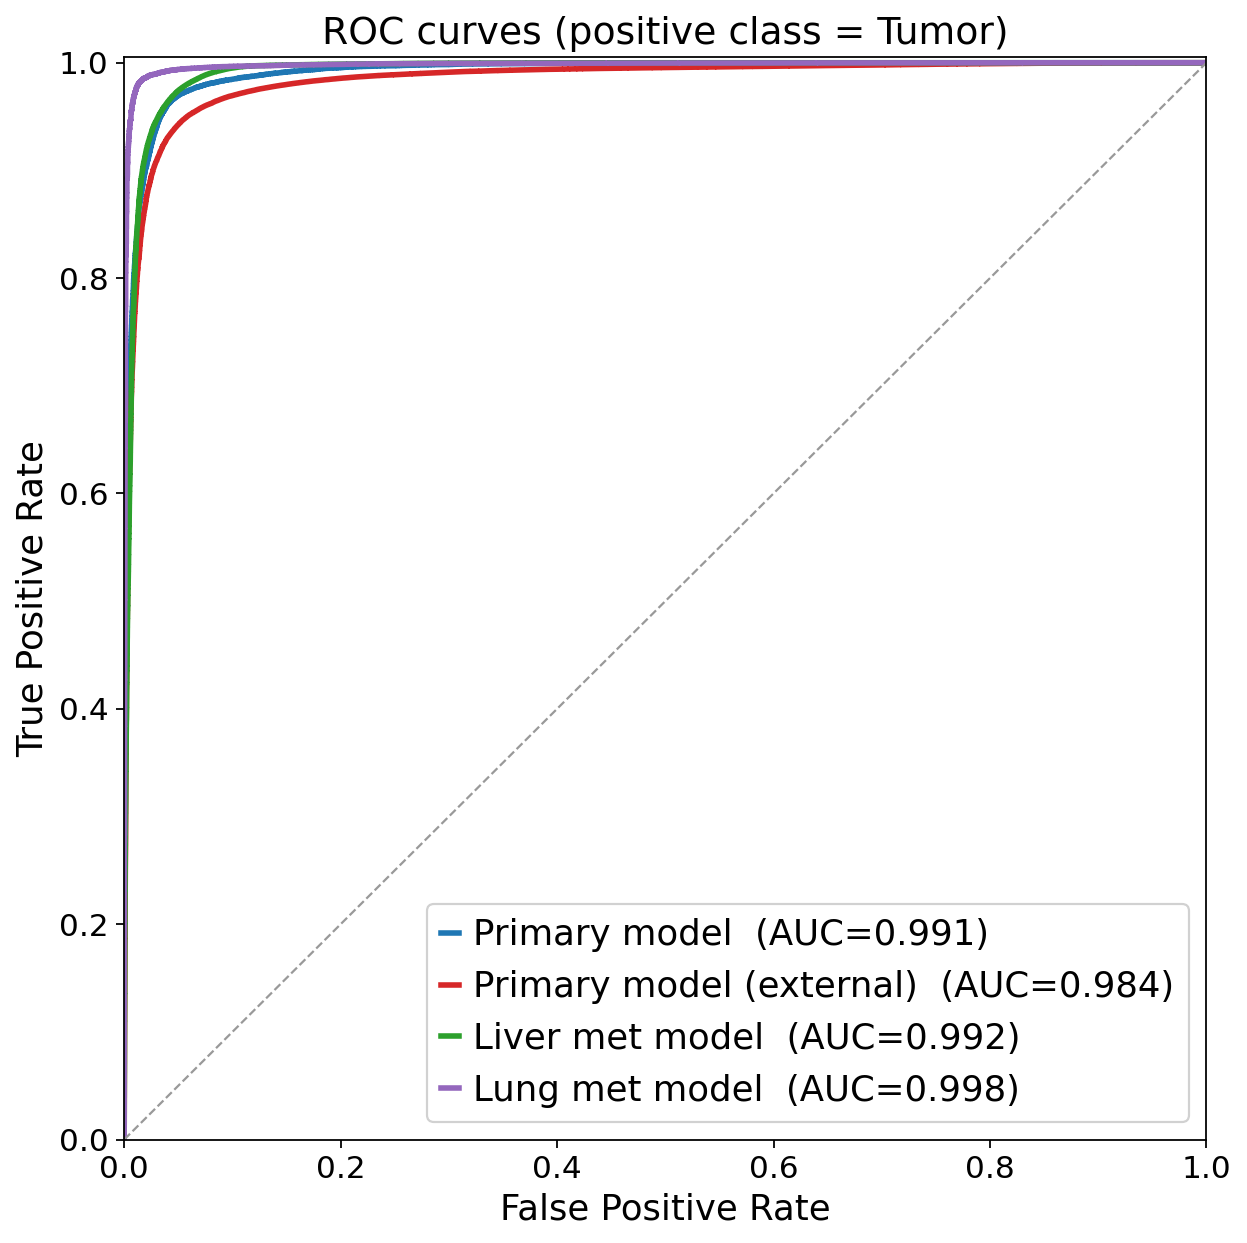

In [ ]:
# ROC curves
Image(str(COMP / "eval_confmat/roc_curves.png"))

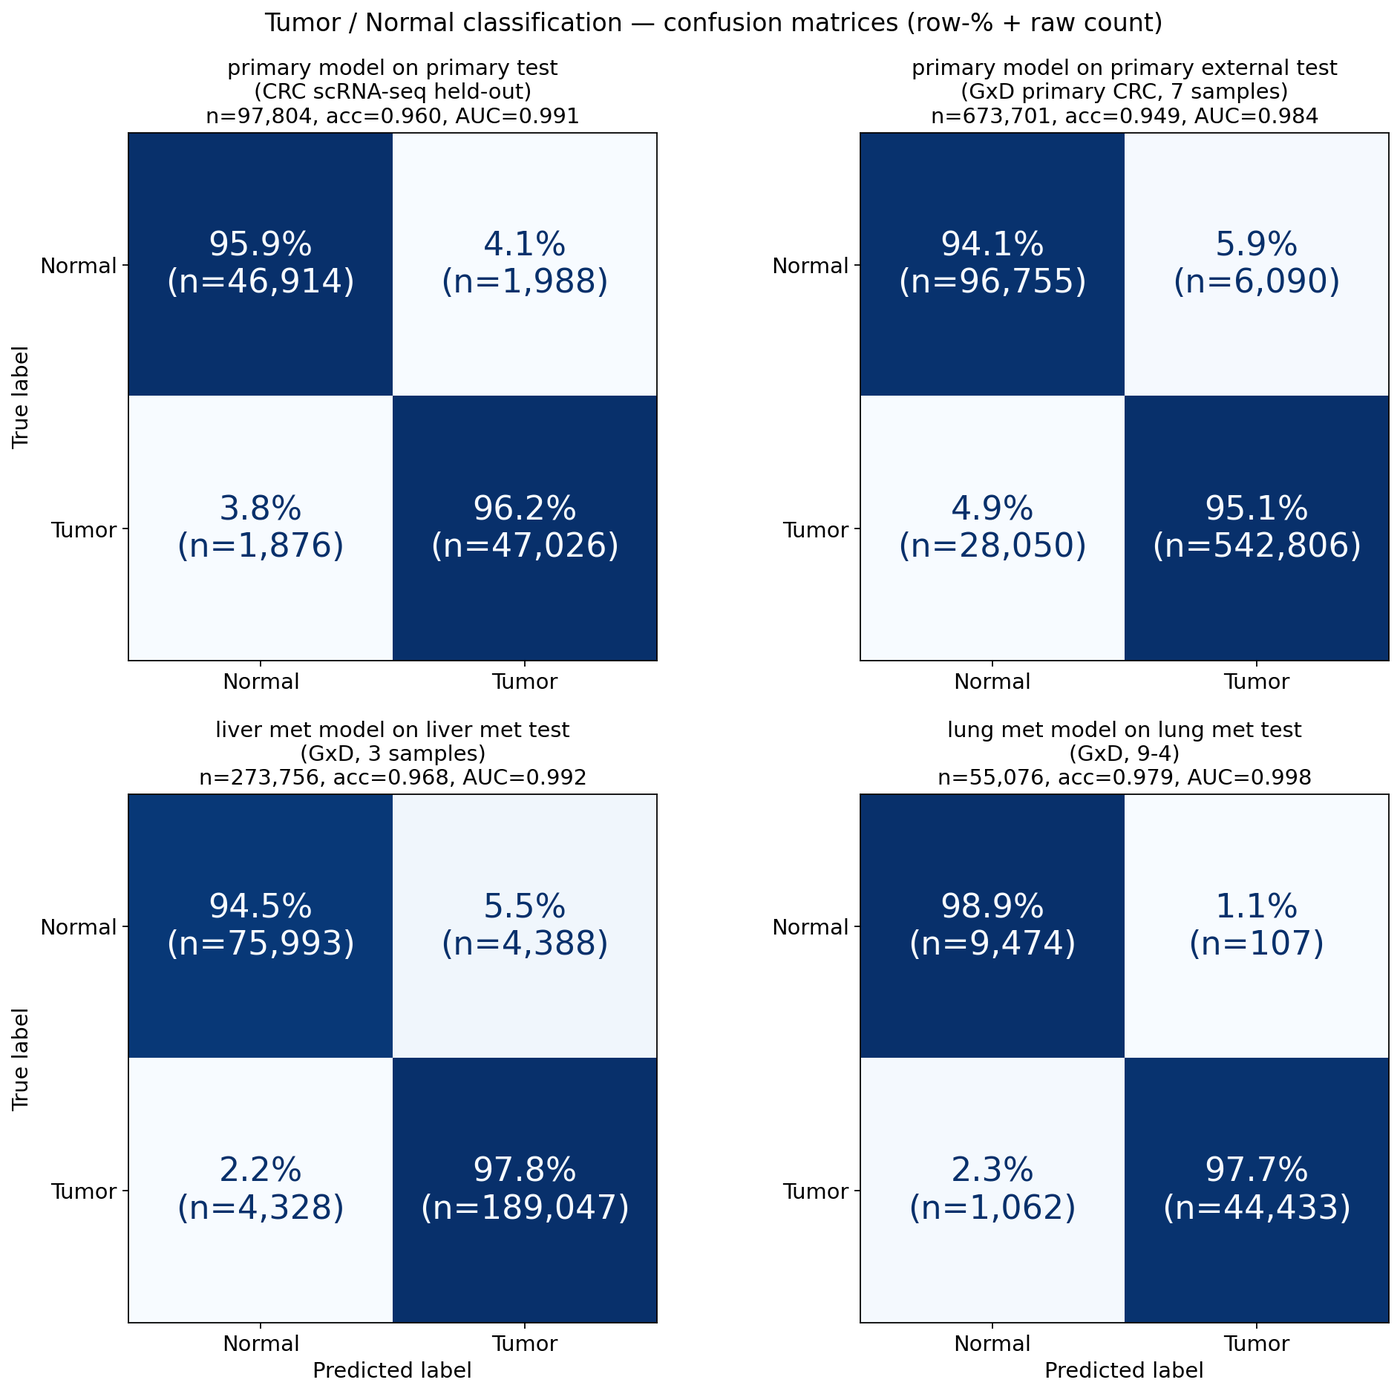

In [ ]:
# Confusion matrices
Image(str(COMP / "eval_confmat/confusion_matrices.png"))

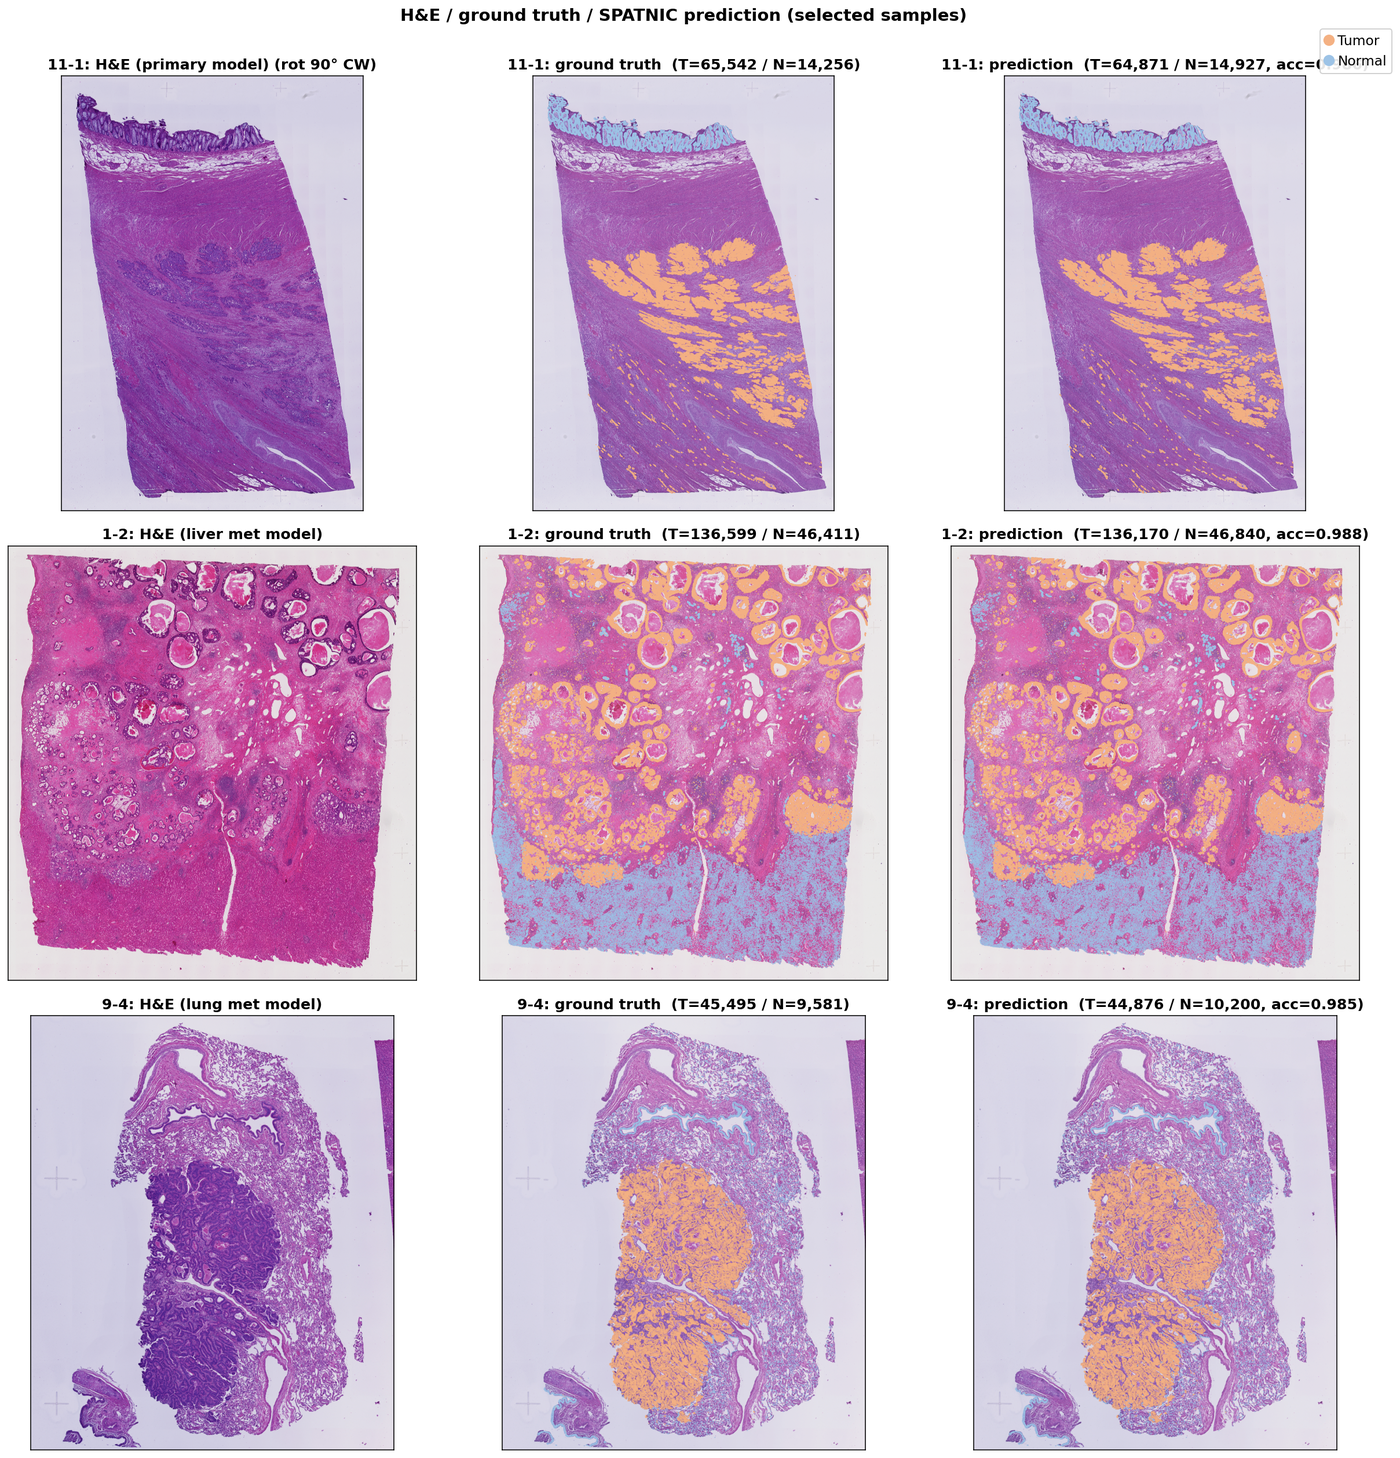

In [ ]:
# GT vs SPATNIC spatial
Image(str(COMP / "eval_confmat/spatial_pred_3samples.png"))